In [5]:
from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure
from skimage.color import label2rgb
import pydicom as dicom
from scipy.stats import norm
from scipy.spatial import distance


In [6]:
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex6-PixelClassificationAndObjectSegmentation/data/"

(512, 512)
int16


/tmp/ipykernel_724186/2430817643.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img, vmin = 20, vmax = 50, cmap = "gray")
/tmp/ipykernel_724186/2430817643.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


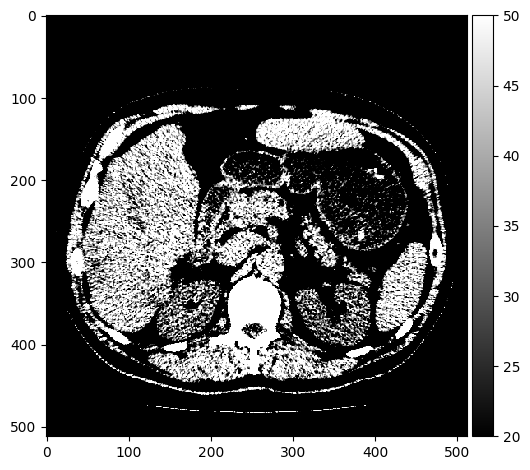

In [7]:
# Lx-6.4 Use Pixel value mapping in io.imshow to get optimal contrast for 16 bit medical scans

ct = dicom.dcmread(path + 'Training.dcm')
img = ct.pixel_array
print(img.shape)
print(img.dtype)

io.imshow(img, vmin = 20, vmax = 50, cmap = "gray")
io.show()

In [8]:
# Lx-6.5 Use a binary segmentation mask to extract pixel values corresponding to the pixels covered by the mask

spleen_roi = io.imread(path + "SpleenROI.png")
spleen_mask = spleen_roi > 0
spleen_values = img[spleen_mask]



In [9]:
# Lx-6.6 Compute the standard measures as the average value and the standard deviation of a selected set of pixel values
mu_spleen = np.mean(spleen_values)
std_spleen = np.std(spleen_values)

print(f"Mean for the spleen: {mu_spleen}, Standard dev for the spleen: {std_spleen} ")


Mean for the spleen: 49.48026905829597, Standard dev for the spleen: 14.9970794143059 


Text(0.5, 1.0, 'Spleen values in CT scan')

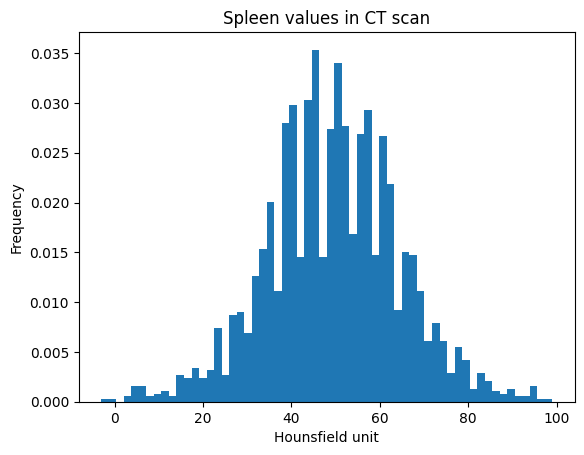

In [10]:
# Lx-6.7: Visualize the histogram of a slected set of pixel values

n, bins, patches = plt.hist(spleen_values, 60, density=1)
plt.xlabel('Hounsfield unit')
plt.ylabel('Frequency')
plt.title('Spleen values in CT scan')




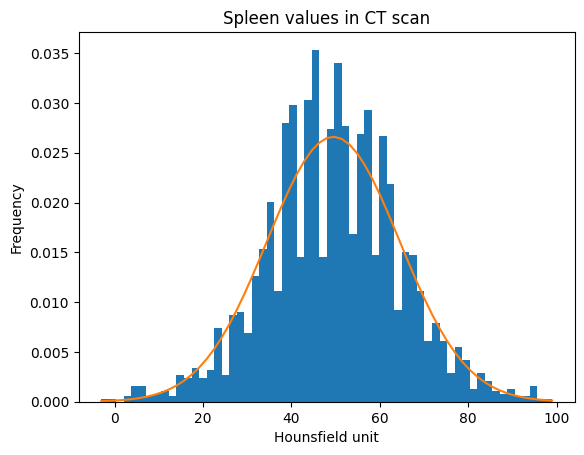

In [11]:
# Lx-6.8 Use SciPy function norm.pdf to sample values in a Gaussian distribution with a given mean and std
# Lx-6.9 Plot a histogram of a selected set of pixel values together with the best fitting gaussian distribution

n, bins, patches = plt.hist(spleen_values, 60, density=1)
pdf_spleen = norm.pdf(bins, mu_spleen, std_spleen)
plt.plot(bins, pdf_spleen)
plt.xlabel('Hounsfield unit')
plt.ylabel('Frequency')
plt.title('Spleen values in CT scan')
plt.show()

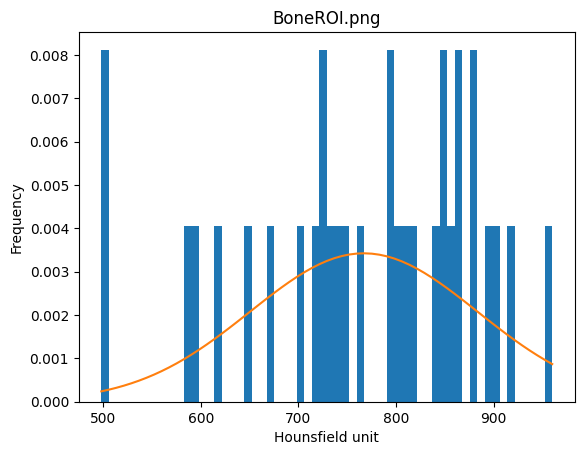

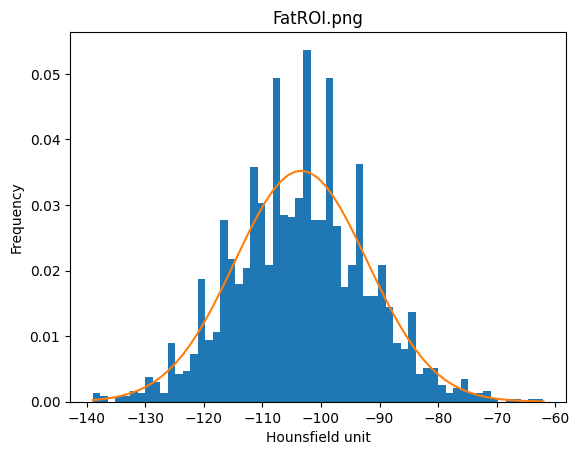

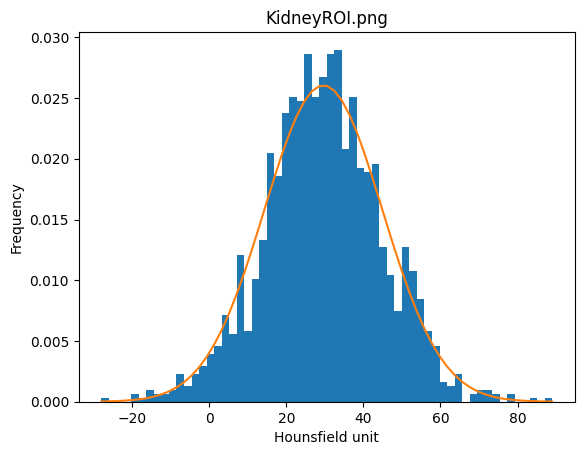

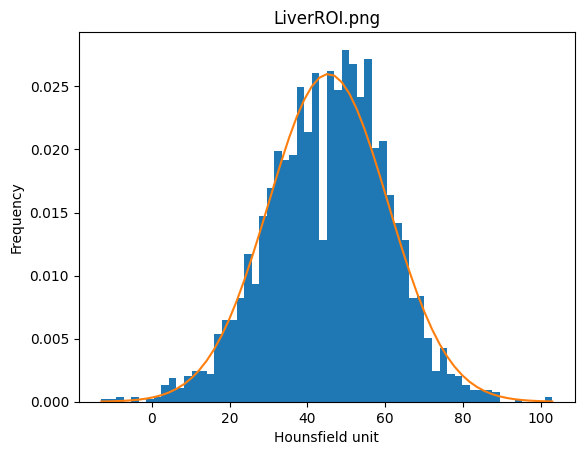

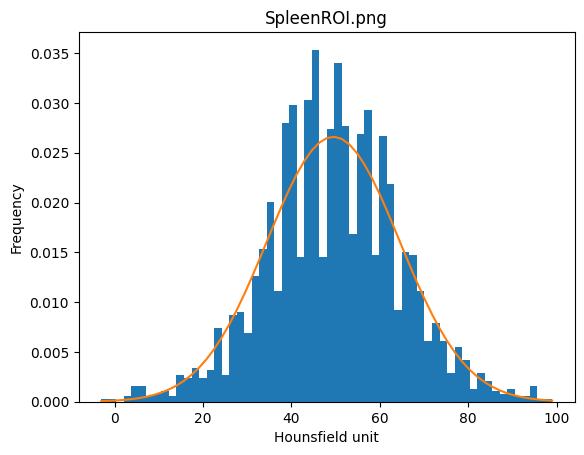

Soft tissue mean: 43.00880789673501 - Bone mean: 766.9375 - Fat mean: -103.39037725533078


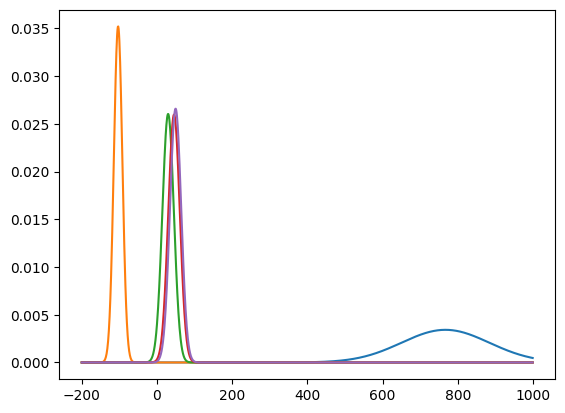

In [12]:
# Lx-6.12 Compute the class ranges using the concept of minimum distance classification
path = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex6-PixelClassificationAndObjectSegmentation/data/"


def load_mask(mask_path):
    roi = io.imread(mask_path)
    mask = roi > 0 #mask is everywhere where its not black
    return mask

def get_values(img, mask_path):
    mask = load_mask(mask_path)
    values = img[mask]
    return values

def get_gaussian_distributions(values, min_hu = -200, max_hu = 1000):
    hu_range = np.arange(min_hu, max_hu, 1.0)
    mu = np.mean(values)
    std = np.std(values)
    pdf = norm.pdf(hu_range, mu, std)
    return pdf



paths = ['BoneROI.png', 'FatROI.png', 'KidneyROI.png', 'LiverROI.png', 'SpleenROI.png']
values = [get_values(img, path + pathos) for pathos in paths]

for value, name in zip(values, paths):
    n, bins, patches = plt.hist(value, 60, density=1)
    mu = np.mean(value)
    std = np.std(value)
    pdf = norm.pdf(bins, mu, std)
    plt.plot(bins, pdf)
    plt.xlabel('Hounsfield unit')
    plt.ylabel('Frequency')
    plt.title(name)
    plt.show()

min_hu, max_hu = -200, 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
pdfs = [get_gaussian_distributions(value) for value in values]

for pdf, path in zip(pdfs, paths): 
    plt.plot(hu_range, pdf, label=path)

vals_soft_tissue = np.concatenate(values[-3:])
soft_tissue_mean = np.mean(vals_soft_tissue)
bone_mean = np.mean(values[0])
fat_mean = np.mean(values[1])



print(f'Soft tissue mean: {soft_tissue_mean} - Bone mean: {bone_mean} - Fat mean: {fat_mean}')
t_background = -200
t_fat_soft = (soft_tissue_mean + fat_mean)/2
t_bone_soft = (soft_tissue_mean + bone_mean)/2
fat_img = (img > t_background) & (img <= t_fat_soft)
soft_img = (img > t_fat_soft) & (img <= t_bone_soft)
bone_img = (img > t_bone_soft)

/tmp/ipykernel_724186/3596884849.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


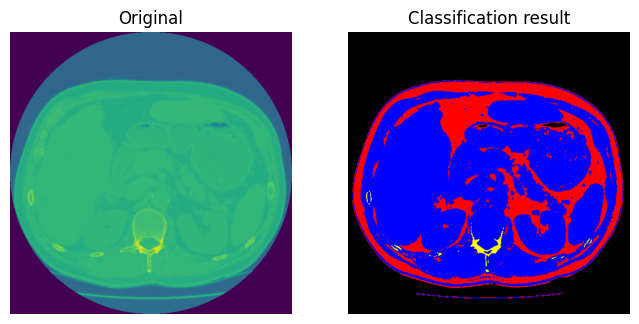

In [13]:
# Lx-6.13 Apply a minimum distance classifier to an image and visualize the results
def show_comparison(original, modified, modified_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True,
                                   sharey=True)
    ax1.imshow(original)
    ax1.set_title('Original')
    ax1.axis('off')
    ax2.imshow(modified)
    ax2.set_title(modified_name)
    ax2.axis('off')
    io.show()


label_img = fat_img + 2 * soft_img + 3 * bone_img
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, 'Classification result')


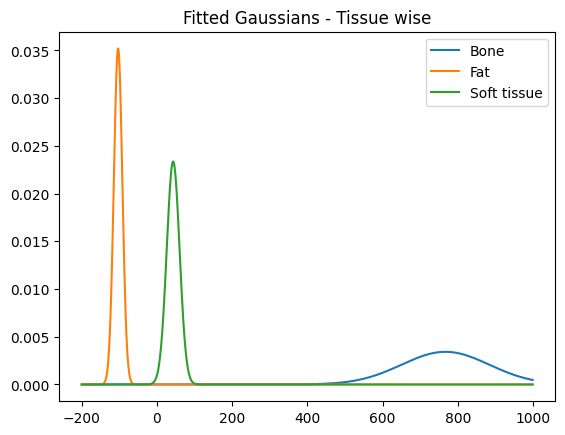

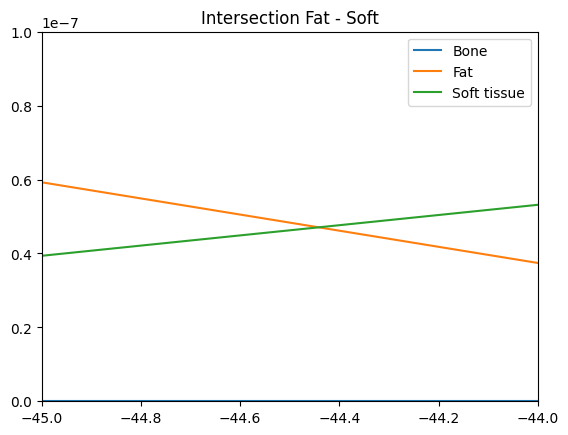

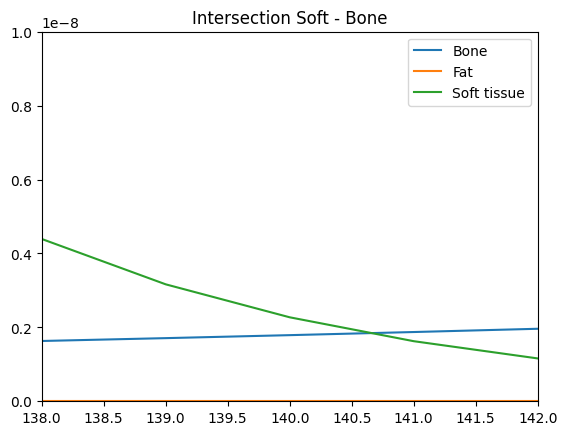

For value 140 the class is soft tissue
For value -45 the class is fat


In [18]:
#Lx-6.15 Compute the class ranges in a parametric classifier by visually inspecting the Gaussians representing each class and manually finding where they cross

# Hounsfield unit limits of the plot
min_hu, max_hu = -200, 1000
hu_range = np.arange(min_hu, max_hu, 1.0)
values_3_classes = [values[0], values[1], vals_soft_tissue]
labels_3_classes = ['Bone', 'Fat', 'Soft tissue']

pdfs_3_classes = [get_gaussian_distributions(value) for value in values_3_classes]

for pdf, path in zip(pdfs_3_classes, labels_3_classes):
    plt.plot(hu_range, pdf, label=path)

plt.title("Fitted Gaussians - Tissue wise")
plt.legend()
plt.show()


# Manual intersection Fat - Soft
for pdf, path in zip(pdfs_3_classes, labels_3_classes):
    plt.plot(hu_range, pdf, label=path)
plt.title("Intersection Fat - Soft")
plt.xlim(-45, -44)
plt.ylim(0, 1e-7)
plt.legend()
plt.show()

# Manual intersection  Soft - Bone
for pdf, path in zip(pdfs_3_classes, labels_3_classes):
    plt.plot(hu_range, pdf, label=path)

plt.title("Intersection Soft - Bone")
plt.xlim(138, 142)
plt.ylim(0, 1e-8)
plt.legend()
plt.show()


# This cell helps you to define an 
# interval for the intersection of the gaussians. 
# Just change the test_value and run the cell again

mu_bone = np.mean(values_3_classes[0])
std_bone = np.std(values_3_classes[0])

mu_fat = np.mean(values_3_classes[1])
std_fat = np.std(values_3_classes[1])

mu_soft = np.mean(values_3_classes[2])
std_soft = np.std(values_3_classes[2])

# Soft vs Bone
test_value = 140
if norm.pdf(test_value, mu_soft, std_soft) > norm.pdf(test_value, mu_bone, std_bone):
    print(f"For value {test_value} the class is soft tissue")
else:
    print(f"For value {test_value} the class is bone")

# Soft vs Fat
test_value = -45
if norm.pdf(test_value, mu_soft, std_soft) > norm.pdf(test_value, mu_fat, std_fat):
    print(f"For value {test_value} the class is soft tissue")
else:
    print(f"For value {test_value} the class is fat")

/tmp/ipykernel_724186/3596884849.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


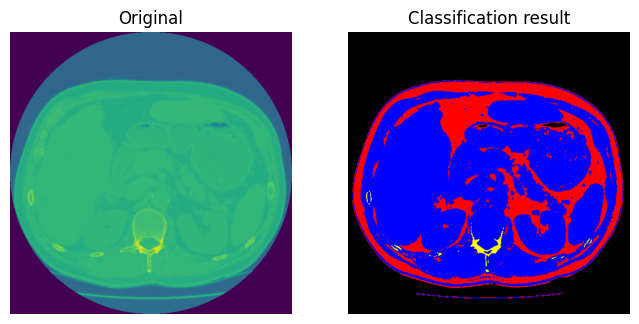

In [25]:
#Lx-6.16 Use norm.pdf to find the class with the highest probability given a pixel value

# Defining binary images and plotting
t_background = -200 # Given from assignment text
fat_img = (img > t_background) & (img <= t_fat_soft)
soft_img = (img > t_fat_soft) & (img <= t_bone_soft)
bone_img = (img > t_bone_soft)

label_img = fat_img + 2 * soft_img + 3 * bone_img
image_label_overlay = label2rgb(label_img)
show_comparison(img, image_label_overlay, 'Classification result')

In [20]:
#Lx-6.17 Use norm.pdf to compute the class ranges by testing the probabilities with a set of pixel values
# Automatic intersection Fat - Soft
for test_value in np.linspace(mu_fat, mu_soft, 1000):
    if norm.pdf(test_value, mu_soft, std_soft) > norm.pdf(test_value, mu_fat, std_fat):
        thres_fat_soft = test_value
        print(f"Fat - Soft threshold: {thres_fat_soft}")
        break

# Automatic intersection Soft - Bone
for test_value in np.linspace(mu_soft, mu_bone, 1000):
    if norm.pdf(test_value, mu_bone, std_bone) > norm.pdf(test_value, mu_soft, std_soft):
        thres_soft_bone = test_value
        print(f"Soft - Bone threshold: {thres_soft_bone}")
        break

Fat - Soft threshold: -44.332447709502425
Soft - Bone threshold: 140.83700953231136


In [ ]:
#Lx-6.18 Apply a parametric classifier to an image and visualize the results

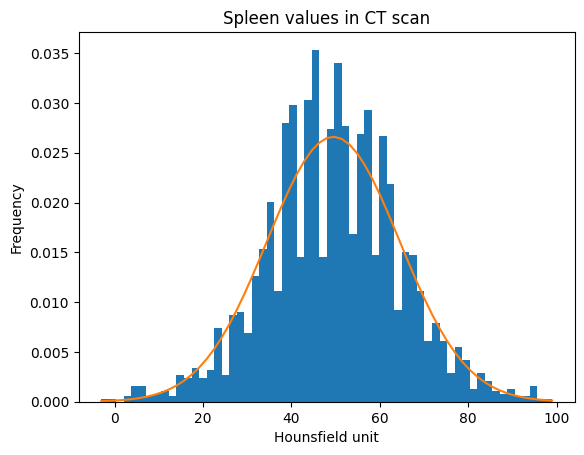

/tmp/ipykernel_724186/4135075714.py:28: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(spleen_label_colour, vmin = t_1, vmax = t_2, cmap = "gray")
/tmp/ipykernel_724186/4135075714.py:30: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


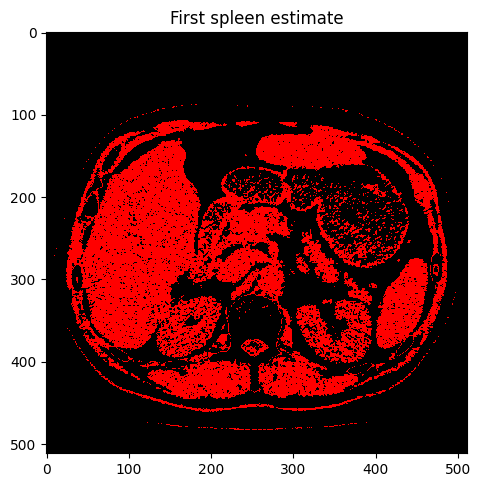

/tmp/ipykernel_724186/4135075714.py:37: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(spleen_label_colour)
/tmp/ipykernel_724186/4135075714.py:39: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


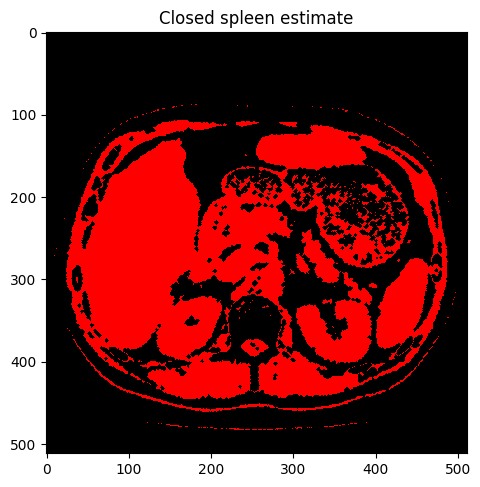

/tmp/ipykernel_724186/4135075714.py:44: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(spleen_label_colour)
/tmp/ipykernel_724186/4135075714.py:46: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


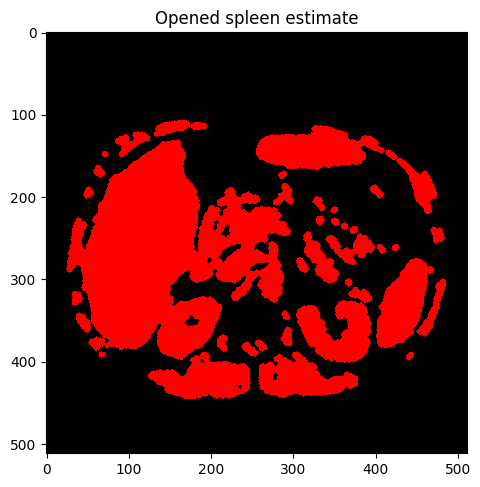

In [26]:
#Lx6.19 Use morpological opening and closing to repair holes in objects and seperate objects in a binary image  
in_dir  = "/home/kkristjansson/DTU/spring2026/02515_Image_Analysis/imageAnalysisGithub/exercises/ex6-PixelClassificationAndObjectSegmentation/data/"

ct = dicom.dcmread(in_dir + 'Training.dcm')
img = ct.pixel_array

path = "SpleenROI.png"
spleen_mask = load_mask(in_dir + path)
spleen_values = img[spleen_mask]

# fig, ax = plt.subplots()
# ax.imshow(spleen_mask)

fig, ax = plt.subplots()
n, bins, patches = ax.hist(spleen_values, 60, density=1)
pdf_spleen = norm.pdf(bins, mu_spleen, std_spleen)
ax.plot(bins, pdf_spleen)
ax.set_xlabel('Hounsfield unit')
ax.set_ylabel('Frequency')
ax.set_title('Spleen values in CT scan')
plt.show()

t_1, t_2 = 20, 80


spleen_estimate = (img > t_1) & (img < t_2)
spleen_label_colour = color.label2rgb(spleen_estimate)
io.imshow(spleen_label_colour, vmin = t_1, vmax = t_2, cmap = "gray")
plt.title("First spleen estimate")
io.show()


footprint = disk(2)
closed = binary_closing(spleen_estimate, footprint)
spleen_label_colour = color.label2rgb(closed)

io.imshow(spleen_label_colour)
plt.title("Closed spleen estimate")
io.show()

footprint = disk(4)
opened = binary_opening(closed, footprint)
spleen_label_colour = color.label2rgb(opened)
io.imshow(spleen_label_colour)
plt.title("Opened spleen estimate")
io.show()



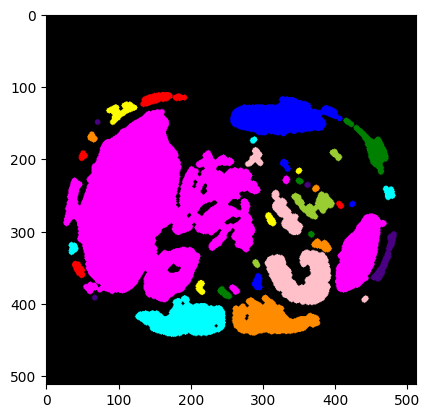

In [30]:
#Lx-6.20 Use BLOB analysis to label objects in a binary image

label_img = measure.label(opened)
im_blob = label2rgb(label_img)

plt.imshow(im_blob)





/tmp/ipykernel_724186/3596884849.py:11: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


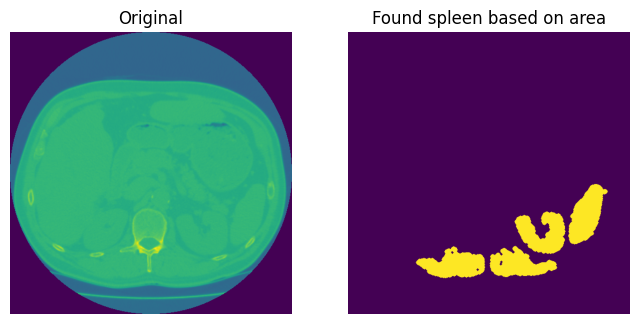

In [ ]:
#Lx-6.21 Use BLOB feature based classification to identify an object in an image. For example the spleen in a computed tomography scan


min_area = 4500
max_area = 4999
region_props = measure.regionprops(label_img)
# Create a copy of the label_img
label_img_filter = label_img.copy()
for region in region_props:
    # Find the areas that do not fit our criteria
    if region.area > max_area or region.area < min_area:
        # set the pixels in the invalid areas to background
        for cords in region.coords:
            label_img_filter[cords[0], cords[1]] = 0
# Create binary image from the filtered label image
i_area = label_img_filter > 0
show_comparison(img, i_area, 'Found spleen based on area')


In [41]:
#Lx-6.23: Compute the DICE score between two segmentations


ground_truth_img = io.imread(in_dir + 'Validation1_spleen.png')
gt_bin = ground_truth_img > 0
dice_score = 1 - distance.dice(i_area.ravel(), gt_bin.ravel())
print(f"DICE score {dice_score}")

DICE score 0.38686770876561993


In [ ]:
#Lx-6.24: Compute and evaluate the DICE score between a computed segmentation and a ground truth segmentation

In [ ]:
#Lx-6.25: Evaluate and optimize a segmentation algorithm based on visual results and DICE score

In [ ]:
#Lx-6.26: Compute the final result of an algorithm on a test set and evaluate the results both visually and using the DICE score